In [1]:
import proximitygraphs as pg
import numpy as np
import matplotlib.pyplot as plt

# Physalum Polycephalum

In [2]:
random_state = 0
points = pg.SetPoints.uniform_square(100, seed=random_state, dims=2)

(<Figure size 800x800 with 1 Axes>, <Axes: >)

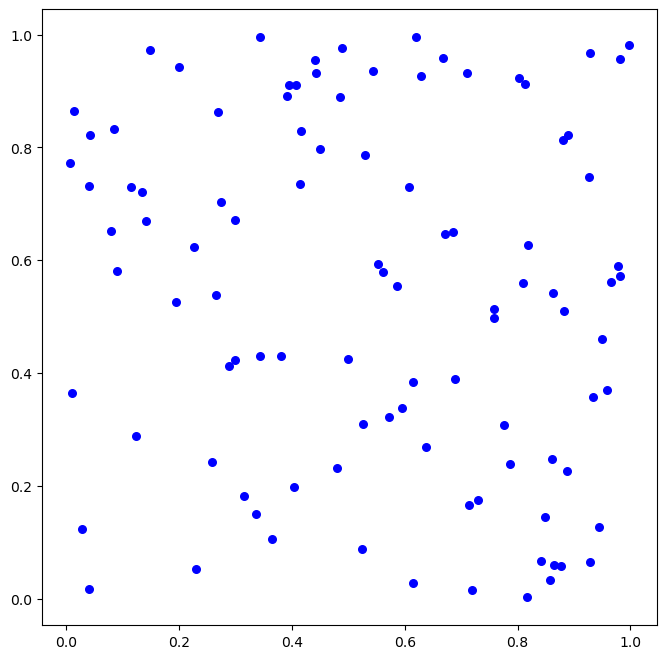

In [3]:
points.draw(figsize=(8, 8), color='blue')

(<Figure size 700x700 with 1 Axes>, <Axes: title={'center': 'Physarum Graph'}>)

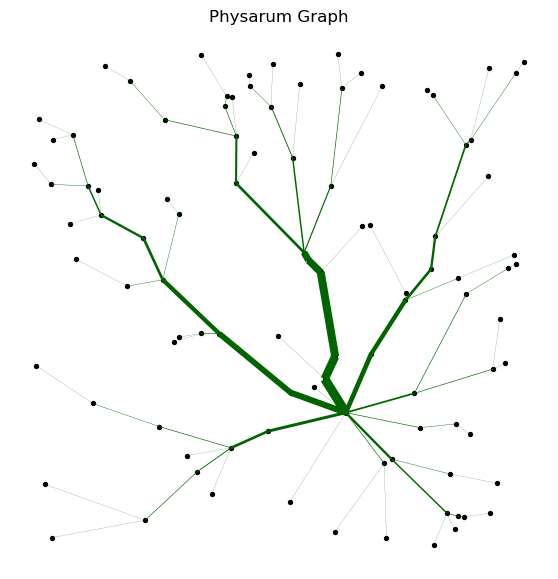

In [4]:
ph = pg.PhysarumGraph(points, sources=[0], sinks=list(range(1, len(points.points))), steps=1000, dt=0.05, gamma=1.2, eps=1e-3, base_graph='delaunay')
ph.draw2(
    figsize=(7, 7),
    e_size=[30 * float(d) for d in ph.graph.es["D"]],
    e_color="darkgreen",
    v_size=8
)

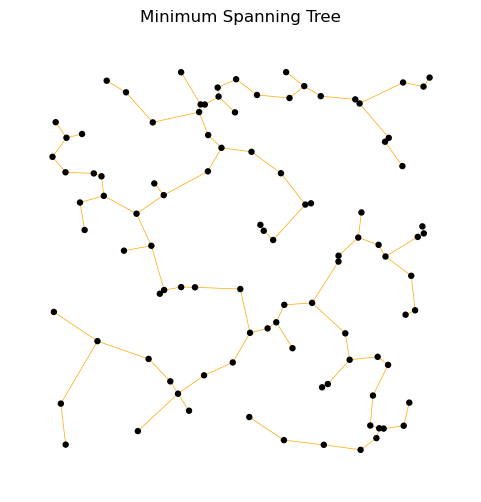

In [5]:
mst = pg.MST(points)
fig, ax = mst.draw(figsize=(6,6), e_size=0.5, e_color="orange")

In [6]:
import matplotlib.cm as cm

In [7]:
ac = pg.biologicalgraphs.AntColonyGraph(points, n_ants=45, steps=200, alpha=1.0, beta=2.0, rho=0.05)
pher_norm = np.array(ac._normalize_pheromones())
cmap = cm.get_cmap('Reds')
colors = [cmap(val) for val in pher_norm]

C:\Users\herie\AppData\Local\Temp\ipykernel_26136\284506257.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Reds')


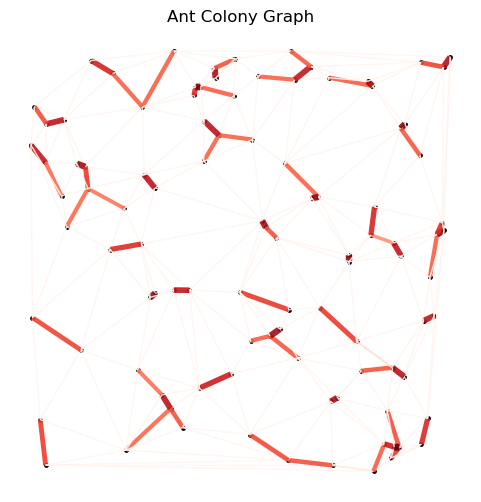

In [8]:
fig2, ax2 = ac.draw2(
    figsize=(6,6),
    e_color=colors,
    e_alpha=0.9,
    e_size=[1 + 4*val for val in pher_norm],
    v_size=6
)